# Sportsbook Market Analysis — Top-5 European Leagues, 2025
**Data:** 1,736 matches, closing 1X2 odds (Bet365, Pinnacle, market max/avg),
results cross-validated across two independent sources.

Questions:
1. **Margins** — What overround do bookmakers price into 1X2 markets,
   and how does it vary by bookmaker and league?
2. **Sharp vs retail** — Where do Pinnacle and Bet365 disagree, and who
   prices closer to observed outcomes?
3. **Calibration** — How well do closing implied probabilities predict
   actual results? Any favorite–longshot bias?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

m = pd.read_csv("../data/processed/matches_2025.csv", parse_dates=["date", "utc_date"])

# Implied probability of outcome i = 1/odds_i.
# Sum across H/D/A exceeds 1; the excess is the bookmaker's margin (overround).
for book in ["b365", "pin", "avg"]:
    inv = (1 / m[[f"{book}_home", f"{book}_draw", f"{book}_away"]]).sum(axis=1)
    m[f"{book}_overround"] = inv - 1

print(m[["b365_overround", "pin_overround", "avg_overround"]].describe().round(4))

       b365_overround  pin_overround  avg_overround
count       1736.0000      1736.0000      1736.0000
mean           0.0565         0.0297         0.0523
std            0.0063         0.0250         0.0076
min            0.0347        -1.0000        -0.0713
25%            0.0526         0.0278         0.0468
50%            0.0563         0.0293         0.0515
75%            0.0600         0.0321         0.0594
max            0.1155         0.0459         0.0727


In [2]:
# Impossible values audit: negative overrounds can't exist; extreme highs
# deserve inspection. Find the offending rows and their raw odds.
suspects = m[
    (m["pin_overround"] < 0)
    | (m["avg_overround"] < 0)
    | (m["b365_overround"] > 0.10)
]
cols = ["league", "date", "home_team", "away_team",
        "b365_home", "b365_draw", "b365_away",
        "pin_home", "pin_draw", "pin_away",
        "avg_home", "avg_draw", "avg_away"]
print(f"Suspect rows: {len(suspects)}")
print(suspects[cols])

Suspect rows: 3
     league       date       home_team   away_team  b365_home  b365_draw  \
821      PD 2025-08-16        Mallorca       Barça       9.50        5.5   
979      PD 2025-12-15  Rayo Vallecano  Real Betis       2.55        3.2   
1734     SA 2025-12-28        Atalanta       Inter       3.20        3.3   

      b365_away  pin_home  pin_draw  pin_away  avg_home  avg_draw  avg_away  
821         1.3      8.06      5.31      1.39      8.70      5.79      1.56  
979         2.9       NaN       NaN       NaN      2.55      3.15      2.88  
1734        2.0      3.51      3.56      2.16      3.41      3.45      2.07  


In [3]:
# Fix 1: recompute overrounds with skipna=False — a match with missing odds
# must have a missing overround, not a nonsense one (the -1.0 artifact).
for book in ["b365", "pin", "avg"]:
    inv = (1 / m[[f"{book}_home", f"{book}_draw", f"{book}_away"]]).sum(axis=1, skipna=False)
    m[f"{book}_overround"] = inv - 1

# Fix 2: two matches carry internally inconsistent market aggregates
# (Avg implies a single-book arbitrage; individual books are normal).
# Source-side aggregation flaw -> void the aggregate columns, keep the match.
bad_agg = m["avg_overround"] < 0
agg_cols = ["max_home", "max_draw", "max_away", "avg_home", "avg_draw", "avg_away", "avg_overround"]
print(f"Voiding aggregate columns on {bad_agg.sum()} rows:")
print(m.loc[bad_agg, ["league", "date", "home_team", "away_team"]])
m.loc[bad_agg, agg_cols] = np.nan

# Re-audit: the only survivor should be B365's legitimate high-margin tail
print(m[["b365_overround", "pin_overround", "avg_overround"]].describe().round(4))

Voiding aggregate columns on 1 rows:
    league       date home_team away_team
821     PD 2025-08-16  Mallorca     Barça
       b365_overround  pin_overround  avg_overround
count       1736.0000      1735.0000      1735.0000
mean           0.0565         0.0303         0.0524
std            0.0063         0.0034         0.0070
min            0.0347         0.0131         0.0342
25%            0.0526         0.0278         0.0468
50%            0.0563         0.0293         0.0515
75%            0.0600         0.0321         0.0594
max            0.1155         0.0459         0.0727


## Q1. Bookmaker margins (overround) by league
The overround is the bookmaker's built-in edge on a 1X2 market.
Baseline finding: Pinnacle ≈ 3.0% vs Bet365 ≈ 5.7% — the "sharp vs
retail" gap. Question here: is the gap uniform, or do books price
leagues differently?

        b365_overround  pin_overround  avg_overround
league                                              
BL1             0.0569         0.0303         0.0533
SA              0.0568         0.0303         0.0536
FL1             0.0565         0.0304         0.0546
PD              0.0563         0.0306         0.0527
PL              0.0562         0.0297         0.0484


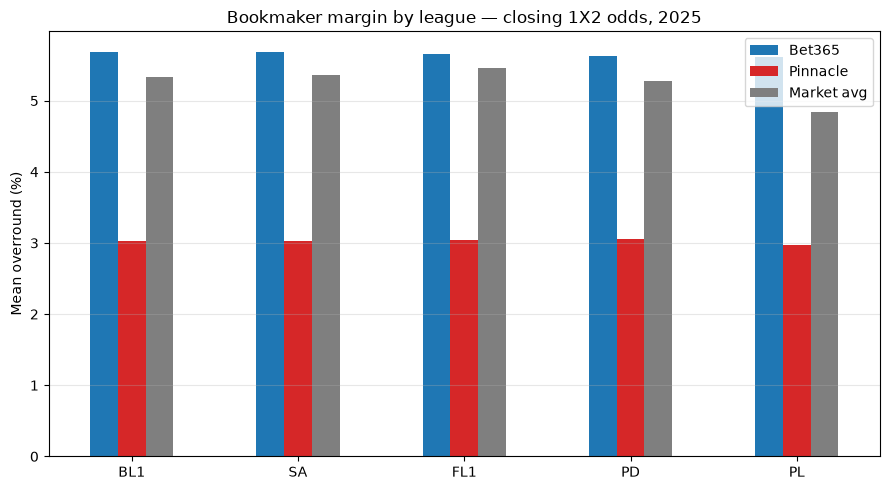

In [4]:
# Margin by bookmaker and league — the project's first headline table
margin_by_league = (
    m.groupby("league")[["b365_overround", "pin_overround", "avg_overround"]]
    .mean()
    .sort_values("b365_overround", ascending=False)
    .round(4)
)
print(margin_by_league)

# Chart: grouped bars, league on x, one bar per book
ax = (margin_by_league * 100).plot(
    kind="bar", figsize=(9, 5), rot=0,
    color=["#1f77b4", "#d62728", "#7f7f7f"],
)
ax.set_ylabel("Mean overround (%)")
ax.set_xlabel("")
ax.set_title("Bookmaker margin by league — closing 1X2 odds, 2025")
ax.legend(["Bet365", "Pinnacle", "Market avg"])
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Is the PL margin dip real?
The market-average margin looks ~0.4pp lower in the PL than elsewhere.
Before claiming "margins compress in liquid markets" we test it:
Welch's t-test (unequal variances) on avg_overround, PL vs other leagues,
plus the effect size — with n≈1700, tiny differences can be "significant"
while meaning nothing, so both numbers matter.

In [5]:
from scipy import stats

pl = m.loc[m["league"] == "PL", "avg_overround"].dropna()
rest = m.loc[m["league"] != "PL", "avg_overround"].dropna()

t, p = stats.ttest_ind(pl, rest, equal_var=False)  # Welch: no equal-variance assumption
pooled_sd = np.sqrt((pl.var() + rest.var()) / 2)
cohens_d = (pl.mean() - rest.mean()) / pooled_sd

print(f"PL mean:   {pl.mean():.4f}  (n={len(pl)})")
print(f"Rest mean: {rest.mean():.4f}  (n={len(rest)})")
print(f"Welch t = {t:.2f}, p = {p:.2e}")
print(f"Cohen's d = {cohens_d:.2f}")

PL mean:   0.0484  (n=378)
Rest mean: 0.0535  (n=1357)
Welch t = -13.81, p = 4.15e-38
Cohen's d = -0.79


**Verdict:** PL margin discount is real and large: 4.84% vs 5.35%
(Welch t = −13.8, p ≈ 4×10⁻³⁸, Cohen's d = −0.79). Retail margins
compress in the most liquid market; Pinnacle, already at the sharp
floor (~3.0%), shows no league effect. Business reading: margin is a
function of competitive pressure, not audience composition.

## Q3. Are closing odds well-calibrated?
Margin-adjusted implied probabilities vs observed outcome frequencies.
Method: normalise each book's three implied probabilities to sum to 1
(strips the overround), pool all 3 × 1736 outcome-probabilities, bin
by implied probability, compare bin midpoint vs realised frequency.
Perfect calibration = points on the diagonal. Favorite–longshot bias
= longshots overpriced (below diagonal at low p), favorites underpriced.

In [8]:
# Reshape: one row per (match, outcome) with normalised implied prob
# and a 0/1 flag for whether that outcome happened. Pinnacle version.
def outcome_table(m: pd.DataFrame, book: str) -> pd.DataFrame:
    inv_h, inv_d, inv_a = (1 / m[f"{book}_home"], 1 / m[f"{book}_draw"], 1 / m[f"{book}_away"])
    total = inv_h + inv_d + inv_a
    rows = []
    for outcome, inv, odds_col in [("H", inv_h, f"{book}_home"),
                                   ("D", inv_d, f"{book}_draw"),
                                   ("A", inv_a, f"{book}_away")]:
        rows.append(pd.DataFrame({
            "implied_prob": inv / total,
            "raw_odds": m[odds_col],
            "happened": (m["result"] == outcome).astype(int),
            "outcome": outcome,
            "league": m["league"],
        }))
    return pd.concat(rows, ignore_index=True).dropna(subset=["implied_prob"])

pin_out = outcome_table(m, "pin")
print(pin_out.shape)                        # expect ~(5205, 4): 3 × 1735
print(pin_out.groupby("outcome")["implied_prob"].mean().round(3))
print("Sanity: mean happened =", pin_out["happened"].mean().round(3))  # ≈ 0.333

(5205, 5)
outcome
A    0.311
D    0.252
H    0.437
Name: implied_prob, dtype: float64
Sanity: mean happened = 0.333


             implied  realised     n
bin                                 
(0.0, 0.05]    0.040     0.000    18
(0.05, 0.1]    0.080     0.058   154
(0.1, 0.15]    0.127     0.090   321
(0.15, 0.2]    0.178     0.185   496
(0.2, 0.25]    0.227     0.246   695
(0.25, 0.3]    0.275     0.244  1141
(0.3, 0.35]    0.319     0.332   617
(0.35, 0.4]    0.375     0.387   328
(0.4, 0.45]    0.423     0.464   302
(0.45, 0.5]    0.474     0.460   252
(0.5, 0.55]    0.524     0.504   238
(0.55, 0.6]    0.574     0.585   171
(0.6, 0.65]    0.625     0.629   140
(0.65, 0.7]    0.674     0.632   106
(0.7, 0.75]    0.721     0.848   105
(0.75, 0.8]    0.774     0.824    68
(0.8, 0.85]    0.819     0.889    36
(0.85, 0.9]    0.872     0.938    16
(0.9, 0.95]    0.927     1.000     1


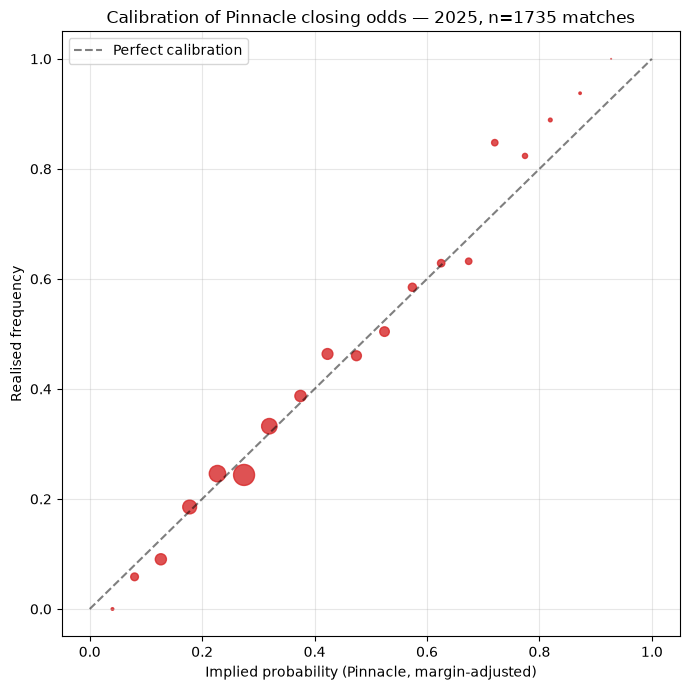

In [10]:
# Bin implied probabilities, compare to realised frequency per bin
bins = np.arange(0, 1.05, 0.05)
pin_out["bin"] = pd.cut(pin_out["implied_prob"], bins)

calib = pin_out.groupby("bin", observed=True).agg(
    implied=("implied_prob", "mean"),
    realised=("happened", "mean"),
    n=("happened", "size"),
)
print(calib.round(3))

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
ax.scatter(calib["implied"], calib["realised"],
           s=calib["n"] / 5, alpha=0.8, color="#d62728")
ax.set_xlabel("Implied probability (Pinnacle, margin-adjusted)")
ax.set_ylabel("Realised frequency")
ax.set_title("Calibration of Pinnacle closing odds — 2025, n=1735 matches")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Quantifying the bias: flat-stake returns by odds band
If odds were perfectly calibrated, a flat 1-unit bet on every outcome
would lose exactly the margin. Deviations by band show where the
bettor's money goes — and where the book's edge concentrates.

In [11]:
# Flat-stake P&L per implied-probability band
pin_out["pnl"] = np.where(pin_out["happened"] == 1, pin_out["raw_odds"] - 1, -1.0)

bands = pd.cut(pin_out["implied_prob"],
               [0, 0.15, 0.35, 0.55, 0.75, 1.0],
               labels=["longshot <15%", "15-35%", "35-55%", "55-75%", "favorite >75%"])
pnl_by_band = pin_out.groupby(bands, observed=True).agg(
    n=("pnl", "size"),
    total_staked=("pnl", "size"),
    mean_return_pct=("pnl", lambda s: 100 * s.mean()),
).round(2)
print(pnl_by_band)

                  n  total_staked  mean_return_pct
implied_prob                                      
longshot <15%   493           493           -34.40
15-35%         2949          2949            -3.90
35-55%         1120          1120            -0.86
55-75%          522           522            -0.15
favorite >75%   121           121             3.36


**Verdict:** Strong favorite–longshot bias in 2025 closing odds.
Flat-stake returns at Pinnacle: −34.4% on longshots (<15% implied,
n=493) rising monotonically to +3.4% on heavy favorites (>75%, n=121;
statistically ≈ break-even). The book's edge concentrates almost
entirely on longshot backers; favorite prices sit near fair value.
Caveats: single-year sample; favorite-band n small; pattern direction
consistent across five adjacent bands, so not a tail artifact.

In [12]:
# Same flat-stake P&L, Bet365 — the retail comparison
b365_out = outcome_table(m, "b365")
b365_out["pnl"] = np.where(b365_out["happened"] == 1, b365_out["raw_odds"] - 1, -1.0)

b365_bands = pd.cut(b365_out["implied_prob"],
                    [0, 0.15, 0.35, 0.55, 0.75, 1.0],
                    labels=["longshot <15%", "15-35%", "35-55%", "55-75%", "favorite >75%"])
b365_pnl = b365_out.groupby(b365_bands, observed=True).agg(
    n=("pnl", "size"),
    mean_return_pct=("pnl", lambda s: 100 * s.mean()),
).round(2)
print(b365_pnl)

                  n  mean_return_pct
implied_prob                        
longshot <15%   451           -43.57
15-35%         2996            -6.56
35-55%         1126            -3.29
55-75%          528            -3.07
favorite >75%   107             4.27


**B365 vs Pinnacle:** retail margin lands asymmetrically. Longshot
returns: −43.6% (B365) vs −34.4% (Pinnacle); mid bands ~3pp worse at
B365 throughout. Heavy favorites: near fair value at BOTH books
(+4.3% / +3.4%, n≈110–120 each, ≈ break-even within noise). The retail
premium is extracted from longshot and mid-range bettors, not
favorite backers. Bands are margin-dependent, so cross-book band
populations differ slightly — direction, not decimals, is the claim.

## Export: Tableau layer
Three tidy CSVs to `data/processed/`, pre-shaped so Tableau does
presentation only, no reshaping:
1. `matches_tableau.csv` — one row per match (margins, results, dates)
2. `calibration_tableau.csv` — binned calibration, long format, both books
3. `pnl_bands_tableau.csv` — flat-stake returns by band, both books

In [13]:
# Export 1, match level:


OUT = Path("../data/processed")

matches_tab = m[[
    "match_id", "league", "date", "matchday",
    "home_team", "away_team", "home_goals", "away_goals", "result",
    "b365_overround", "pin_overround", "avg_overround",
]].copy()
# Tableau-friendly niceties: full league names, readable result
league_names = {"PL": "Premier League", "PD": "La Liga", "BL1": "Bundesliga",
                "SA": "Serie A", "FL1": "Ligue 1"}
matches_tab["league_name"] = matches_tab["league"].map(league_names)
matches_tab["result_label"] = matches_tab["result"].map(
    {"H": "Home win", "D": "Draw", "A": "Away win"})

matches_tab.to_csv(OUT / "matches_tableau.csv", index=False)
print("matches_tableau:", matches_tab.shape)

matches_tableau: (1736, 14)


In [14]:
#  export 2, calibration long format

def calibration_frame(out_table: pd.DataFrame, label: str) -> pd.DataFrame:
    binned = pd.cut(out_table["implied_prob"], np.arange(0, 1.05, 0.05))
    c = out_table.groupby(binned, observed=True).agg(
        implied=("implied_prob", "mean"),
        realised=("happened", "mean"),
        n=("happened", "size"),
    ).reset_index(names="prob_bin")
    c["prob_bin"] = c["prob_bin"].astype(str)   # Interval objects don't survive CSV
    c["bookmaker"] = label
    return c

calib_tab = pd.concat([
    calibration_frame(pin_out, "Pinnacle"),
    calibration_frame(b365_out, "Bet365"),
], ignore_index=True)
calib_tab.to_csv(OUT / "calibration_tableau.csv", index=False)
print("calibration_tableau:", calib_tab.shape)

calibration_tableau: (38, 5)


In [15]:
#  export 3, P&L bands, same stacking pattern:

def pnl_frame(out_table: pd.DataFrame, label: str) -> pd.DataFrame:
    out = out_table.copy()
    out["pnl"] = np.where(out["happened"] == 1, out["raw_odds"] - 1, -1.0)
    bands = pd.cut(out["implied_prob"], [0, 0.15, 0.35, 0.55, 0.75, 1.0],
                   labels=["longshot <15%", "15-35%", "35-55%", "55-75%", "favorite >75%"])
    p = out.groupby(bands, observed=True).agg(
        n=("pnl", "size"),
        mean_return_pct=("pnl", lambda s: 100 * s.mean()),
    ).reset_index(names="band")
    p["bookmaker"] = label
    return p

pnl_tab = pd.concat([pnl_frame(pin_out, "Pinnacle"),
                     pnl_frame(b365_out, "Bet365")], ignore_index=True)
pnl_tab.to_csv(OUT / "pnl_bands_tableau.csv", index=False)
print("pnl_bands_tableau:", pnl_tab.shape)


pnl_bands_tableau: (10, 4)
